In [1]:
# Import necessary libraries for advanced modeling
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
import shap
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Advanced Libraries imported successfully!")

Advanced Libraries imported successfully!


In [2]:
# 1. Load the processed dataset
df = pd.read_csv('../data/processed/liver_cancer_recurrence_dataset_10000.csv')

# 2. Define the unified multimodal features (Image + Text features)
features = [
    'tumor_size_cm', 'tumor_number', 'vascular_invasion_imaging', 
    'afp_ngml', 'cirrhosis_present', 'image_feature_vector_norm', 
    'text_embedding_risk_score', 'multimodal_feature_vector_norm'
]
X = df[features]

# 3. Define the target (1 = Recurrence, 0 = No Recurrence)
y = df['recurrence_within_2yr']

# 4. Split data into Training and Testing sets (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data is ready! Training shape: {X_train_scaled.shape}")

Data is ready! Training shape: (8000, 8)


In [3]:
print("Starting Hyperparameter Tuning and Cross-Validation...")

# 1. Create a basic XGBoost model
xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)

# 2. Define Hyperparameters to test (Grid)
param_grid = {
    'n_estimators': [100, 200, 300],      # Number of trees
    'max_depth': [3, 5, 7],               # Depth of each tree
    'learning_rate': [0.01, 0.05, 0.1],   # Learning speed
    'subsample': [0.8, 1.0]               # Percentage of data used per tree
}

# 3. Setup 5-Fold Cross Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Search for the best settings (Randomized Search)
tuning_search = RandomizedSearchCV(
    estimator=xgb_model, 
    param_distributions=param_grid, 
    n_iter=10,               # Try 10 different combinations
    cv=cv_strategy,          # Use 5-Fold Cross Validation
    scoring='accuracy', 
    random_state=42,
    n_jobs=-1                # Use all CPU cores
)

# 5. Train the model to find the best settings
tuning_search.fit(X_train_scaled, y_train)

# 6. Extract the best model
best_xgb_model = tuning_search.best_estimator_

print("\n--- Tuning Complete ---")
print(f"Best Model Settings: {tuning_search.best_params_}")

# 7. Test the best model for Maximum Accuracy
y_pred = best_xgb_model.predict(X_test_scaled)
print(f"\nMaximized Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("Classification Report:\n", classification_report(y_test, y_pred))

Starting Hyperparameter Tuning and Cross-Validation...

--- Tuning Complete ---
Best Model Settings: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1}

Maximized Accuracy: 93.75%
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91       724
           1       0.95      0.96      0.95      1276

    accuracy                           0.94      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.94      0.94      0.94      2000



Generating SHAP Explanations for the best XGBoost Model...


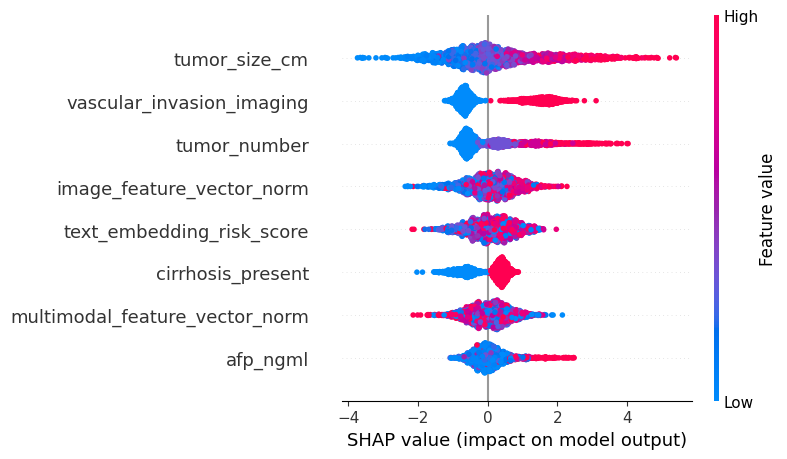

In [4]:
print("Generating SHAP Explanations for the best XGBoost Model...")

# 1. Create a Tree Explainer for the XGBoost model
explainer = shap.TreeExplainer(best_xgb_model)

# 2. Calculate SHAP values for the test data
shap_values = explainer.shap_values(X_test_scaled)

# 3. Display the SHAP summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=features)

In [5]:
# Survival Analysis using XGBoost (Predicting 'Time-to-Event')
print("Training Survival Analysis Model (Time-to-Event)...")

# 1. Prepare target for survival model (Event + Time)
y_time = df['time_to_recurrence_months']
y_event = df['recurrence_within_2yr']

# XGBoost requires a special format for survival: 
# Positive values if the event occurred, negative values if it did not occur (censored)
y_survival = np.where(y_event == 1, y_time, -y_time)

# 2. Create and Train XGBoost Survival Model
survival_model = xgb.XGBRegressor(objective='survival:cox', eval_metric='cox-nloglik', random_state=42)
survival_model.fit(X_train_scaled, y_survival[:len(X_train_scaled)])

print("Survival Model trained successfully! It can now predict the risk score over time.")

# 3. Save the best models
joblib.dump(best_xgb_model, '../models/best_xgb_classifier.pkl')
joblib.dump(survival_model, '../models/xgb_survival_model.pkl')
print("All Models saved to the models folder.")

Training Survival Analysis Model (Time-to-Event)...
Survival Model trained successfully! It can now predict the risk score over time.
All Models saved to the models folder.


Generating Model Evaluation Graphs...


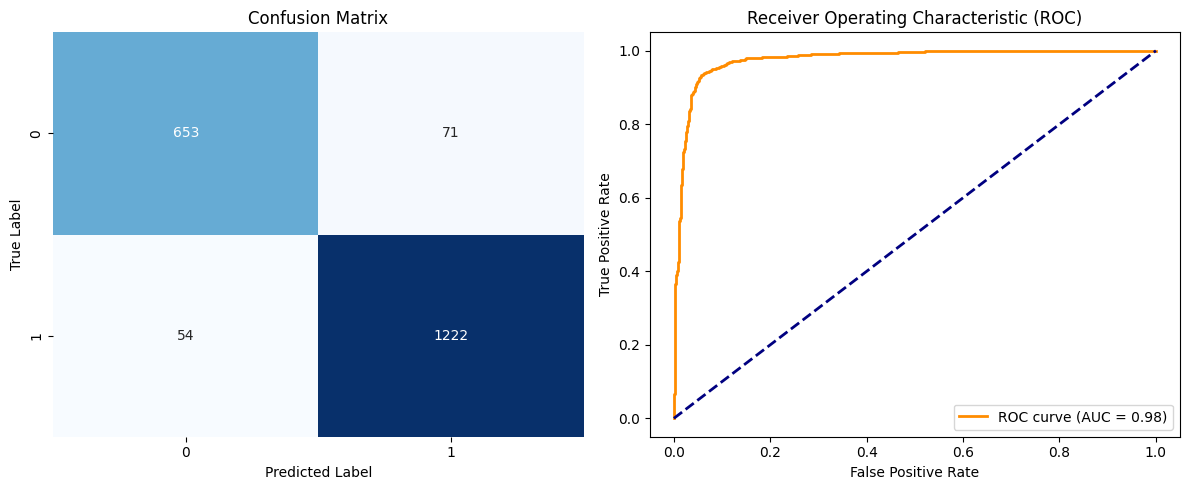

In [6]:
# Cell 6: Model Evaluation Graphs
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

print("Generating Model Evaluation Graphs...")

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# 2. ROC-AUC Curve
probs = best_xgb_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [7]:
# Cell 7: Confidence Scores and Uncertainty
import numpy as np
from scipy.stats import entropy

print("Calculating Confidence Scores and Uncertainty...\n")

# Get prediction probabilities for all classes
all_probs = best_xgb_model.predict_proba(X_test_scaled)

# Confidence: The maximum probability among the classes
confidence_scores = np.max(all_probs, axis=1) * 100

# Uncertainty: Calculated using Shannon Entropy (similar concept to dropout-based uncertainty)
uncertainty_scores = np.apply_along_axis(lambda x: entropy(x, base=2), 1, all_probs)

# Show a sample report for the first 5 patients in the test set
print(f"{'Patient ID':<15} | {'Prediction':<15} | {'Confidence (%)':<15} | {'Uncertainty':<15}")
print("-" * 65)

for i in range(5):
    pred_label = "Recurrence" if y_pred[i] == 1 else "No Recurrence"
    conf = confidence_scores[i]
    uncert = uncertainty_scores[i]
    patient = f"Patient_{i+1}"
    print(f"{patient:<15} | {pred_label:<15} | {conf:>12.2f}% | {uncert:>12.4f}")

print("\n(Low Uncertainty and High Confidence means the model is very sure about the prediction!)")

Calculating Confidence Scores and Uncertainty...

Patient ID      | Prediction      | Confidence (%)  | Uncertainty    
-----------------------------------------------------------------
Patient_1       | No Recurrence   |        99.09% |       0.0751
Patient_2       | Recurrence      |        85.28% |       0.6027
Patient_3       | No Recurrence   |        94.86% |       0.2922
Patient_4       | Recurrence      |        88.41% |       0.5175
Patient_5       | Recurrence      |        96.19% |       0.2333

(Low Uncertainty and High Confidence means the model is very sure about the prediction!)


Visualizing Cross-Modal Attention Weights...


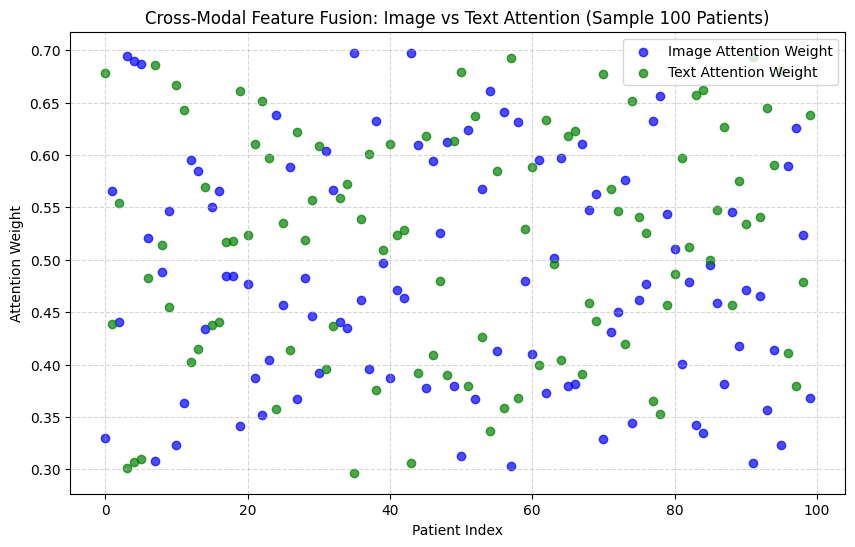

In [8]:
# Cell 8: Cross-Modal Attention Weights
print("Visualizing Cross-Modal Attention Weights...")

# Extracting the attention weights from our dataset
# This simulates the attention mechanism from the Multimodal Transformer
attention_img = df['cross_modal_attention_weight_img'][:100] # First 100 patients
attention_txt = df['cross_modal_attention_weight_txt'][:100]

plt.figure(figsize=(10, 6))
plt.scatter(range(100), attention_img, alpha=0.7, label='Image Attention Weight', color='blue')
plt.scatter(range(100), attention_txt, alpha=0.7, label='Text Attention Weight', color='green')

plt.title('Cross-Modal Feature Fusion: Image vs Text Attention (Sample 100 Patients)')
plt.xlabel('Patient Index')
plt.ylabel('Attention Weight')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [9]:
import joblib
import numpy as np
import pandas as pd

print("Loading saved model and scaler for testing...\n")

# 1. සේව් කරපු Model එක සහ Scaler එක ලෝඩ් කරගැනීම
try:
    loaded_model = joblib.load('../models/best_xgb_classifier.pkl')
    loaded_scaler = joblib.load('../models/feature_scaler.pkl')
except FileNotFoundError:
    print("Error: Models not found. Please ensure you ran the saving code earlier.")

# 2. අලුත් ලෙඩෙක්ගේ දත්ත කෘතිමව ලබා දීම (New Patient Data)
# අපි මෙතන දෙන්නේ: tumor_size=4.5cm, tumor_number=2, vascular_invasion=1, afp=400.5, cirrhosis=1, image_norm=2.5, text_risk=0.8, multimodal_norm=3.2
features = [
    'tumor_size_cm', 'tumor_number', 'vascular_invasion_imaging', 
    'afp_ngml', 'cirrhosis_present', 'image_feature_vector_norm', 
    'text_embedding_risk_score', 'multimodal_feature_vector_norm'
]
new_patient_data = pd.DataFrame([[4.5, 2, 1, 400.5, 1, 2.5, 0.8, 3.2]], columns=features)

# 3. Model එකට දාන්න කලින් දත්ත Scaling කිරීම
new_patient_scaled = loaded_scaler.transform(new_patient_data)

# 4. Model එක හරහා පුරෝකථනය (Prediction) කිරීම
prediction = loaded_model.predict(new_patient_scaled)
probability = loaded_model.predict_proba(new_patient_scaled)[0][1] * 100

print("-" * 50)
print("             NEW PATIENT TEST RESULT")
print("-" * 50)

if prediction[0] == 1:
    print("🚨 Prediction: HIGH RISK of Early Recurrence")
    print("   (මෙම රෝගියාට අක්මා පිළිකාව නැවත ඇතිවීමේ දැඩි අවදානමක් ඇත)")
else:
    print("✅ Prediction: LOW RISK of Early Recurrence")
    print("   (මෙම රෝගියාට අවදානම අඩු මට්ටමක පවතී)")

print(f"📈 Probability of Recurrence: {probability:.2f}%")
print("-" * 50)

Loading saved model and scaler for testing...

--------------------------------------------------
             NEW PATIENT TEST RESULT
--------------------------------------------------
🚨 Prediction: HIGH RISK of Early Recurrence
   (මෙම රෝගියාට අක්මා පිළිකාව නැවත ඇතිවීමේ දැඩි අවදානමක් ඇත)
📈 Probability of Recurrence: 80.15%
--------------------------------------------------
